# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**: Daniella Yuka Hirosue, Lara Oliveira Luzeiro, Renan Yugo Ueda

**RA**: 813008, 813259, 813346


---
## Preparação do Ambiente

In [1]:
%load_ext autoreload
%autoreload 2

# Manipulação de Dados
import pandas as pd
import numpy as np

# Manipulação de arquivos
import os
import sys

# Visualização de Dados
import seaborn as sns
import matplotlib.pyplot as plt

# Importa funções dos scripts
SCRIPT_DIR = os.path.join(os.getcwd(), 'scripts')
sys.path.append(SCRIPT_DIR)
from analise_exploratoria import informacoes_gerais, distribuicao_classes, analisar_duplicados, problemas_codificacao, medidas_descritivas, tamanho_por_categoria, analisar_referencias_legais, analise_lexical, diversidade_por_categoria, palavras_por_categoria, bigramas_frequentes, grafico_distribuicao_classes, boxplot_tamanho_textos, histograma_tamanho_textos, grafico_referencias_legais, palavras_frequentes

---

## Carregamento de Dados

In [2]:
df = pd.read_csv("../ufscar-pln2026-pf/train.csv")

print(df.shape)
df.head()

(22680, 3)


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimen...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazen...",3


---
## Análise Exploratória

A etapa de análise exploratória teve como objetivo compreender a estrutura do conjunto de dados, identificar possíveis problemas de qualidade e extrair informações relevantes que auxiliem na etapa de pré-processamento.

O conjunto de dados disponibilizado é composto por documentos jurídicos rotulados em diferentes categorias. Cada instância representa um documento associado a uma classe que será utilizada como variável alvo no problema de classificação.

### Significado dos Atributos

* `Id(Identificador)`: Um número inteiro único e sequencial atribuído a cada documento do conjunto de dados para auxiliar na rastreabilidade. 

* `Body (Corpo do Texto)`: Texto bruto extraído das páginas em PDF dos processos judiciais do STF. 

* `Category (Categoria / Rótulo)`: Rótulo numérico que identifica qual é o tipo daquele documento (Acórdão, Recurso Extraordinário, Agravo de Recurso Extraordinário, Despacho ou Sentença).

### Informações Gerais

Esta seção tem como objetivo fornecer uma visão inicial do conjunto de dados. Foram analisadas características básicas, como quantidade de documentos, número de categorias, presença de valores ausentes, documentos duplicados e possíveis problemas de codificação textual. Essas informações permitem avaliar a qualidade dos dados e identificar possíveis etapas de pré-processamento necessárias. 

In [3]:
informacoes_gerais(df)
distribuicao_classes(df)
analisar_duplicados(df)
problemas_codificacao(df)


INFORMACOES GERAIS
Quantidade de documentos: 22680
Quantidade de atributos: 3
Quantidade de categorias: 6

Valores nulos:
Id          0
Body        0
Category    0
dtype: int64

DISTRIBUICAO DAS CLASSES

Distribuicao das classes:
Category
 3    12876
 1     3529
 4     2903
-1     2268
 0      665
 2      439
Name: count, dtype: int64

Distribuicao percentual das classes:
Category
 3    56.77
 1    15.56
 4    12.80
-1    10.00
 0     2.93
 2     1.94
Name: proportion, dtype: float64

DOCUMENTOS DUPLICADOS
Quantidade de duplicados: 11183
Percentual: 49.31%

PROBLEMAS DE CODIFICACAO
Documentos afetados: 22644
Percentual: 99.84%


### Medidas Descritivas

Nesta etapa são analisadas características quantitativas dos documentos, com foco no tamanho dos textos e na distribuição dessas medidas entre as categorias. Além disso, são investigadas informações específicas do domínio jurídico, como a frequência de referências legislativas. Essas análises auxiliam na compreensão da complexidade dos dados e na identificação de padrões que podem contribuir para a tarefa de classificação.

In [4]:
medidas_descritivas(df)
tamanho_por_categoria(df)
analisar_referencias_legais(df)


MEDIDAS DESCRITIVAS

Estatisticas do tamanho dos documentos:
count    22680.000000
mean       216.426058
std         93.088142
min          1.000000
25%        159.000000
50%        209.000000
75%        268.000000
max        844.000000
Name: word_count, dtype: float64

Menor documento: 1 palavras
Maior documento: 844 palavras
Media de palavras por documento: 216.43

TAMANHO DOS DOCUMENTOS POR CLASSE
          count        mean  median  min  max         std
Category                                                 
-1         2268  218.045414   210.0    1  729   95.421264
 0          665  251.539850   262.0   19  576  114.338256
 1         3529  195.200057   181.0    1  685   90.091137
 2          439  149.036446   152.0   14  844  102.660404
 3        12876  213.882883   206.0    4  781   87.938303
 4         2903  254.391319   243.0   13  837   94.121400

REFERENCIAS LEGISLATIVAS
count    22680.000000
mean         4.141623
std          3.822735
min          0.000000
25%          1.00

### Análise Lexical

A análise lexical busca compreender o conteúdo linguístico dos documentos. Para isso, foram avaliados aspectos como tamanho do vocabulário, diversidade lexical, palavras mais frequentes, termos característicos de cada categoria e expressões recorrentes do domínio jurídico. Os resultados desta etapa ajudam a identificar padrões linguísticos relevantes e fornecem indícios sobre quais técnicas de representação textual podem ser mais adequadas para o problema.

In [5]:
common_words = analise_lexical(df)
diversidade_por_categoria(df)
palavras_por_categoria(df)
bigramas_frequentes(df)


ANALISE LEXICAL
Tamanho do vocabulario: 22524
Diversidade lexical: 0.0230

Top 15 palavras mais frequentes:
artigo: 16034
dos: 10636
lei: 10557
por: 8959
federal: 7586
recurso: 6304
pela: 5359
aos: 5259
geral: 5244
como: 5139
ser: 4623
fazenda: 4394
nos: 4372
pelo: 4277
direito: 4221

DIVERSIDADE LEXICAL POR CLASSE
Classe -1: 0.0372
Classe 0: 0.0363
Classe 1: 0.0315
Classe 2: 0.0704
Classe 3: 0.0118
Classe 4: 0.0209

PALAVRAS MAIS FREQUENTES POR CLASSE

Classe -1
artigo: 7273
lei: 4806
dos: 4760
por: 4124
federal: 3393
recurso: 2881
aos: 2454
pela: 2416
geral: 2408
como: 2311

Classe 0
dos: 2719
artigo: 2178
lei: 1728
por: 1592
nos: 1218
ser: 1057
recurso: 1041
federal: 1041
parte: 938
aos: 906

Classe 1
artigo: 7591
recurso: 7296
por: 6193
dos: 5696
federal: 4951
lei: 4327
decisão: 4057
extraordinário: 4048
como: 3833
ser: 3538

Classe 2
recurso: 1426
artigo: 1173
agravo: 917
extraordinário: 871
decisão: 778
federal: 743
dos: 714
recursal: 677
turma: 654
tribunal: 568

Classe 3
artig

### Gráficos

Os gráficos complementam as análises anteriores, facilitando a interpretação da distribuição dos dados. São apresentados gráficos relacionados à distribuição das categorias, ao tamanho dos documentos, à frequência de referências legislativas e aos termos mais recorrentes. Essas representações facilitam a identificação de tendências, discrepâncias e padrões relevantes para o desenvolvimento do modelo de classificação.

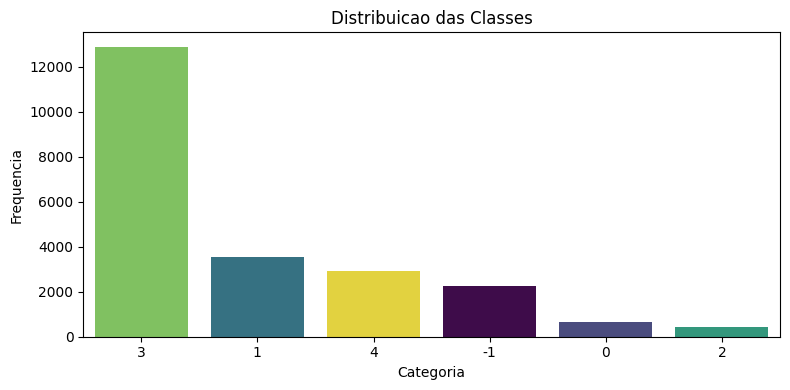

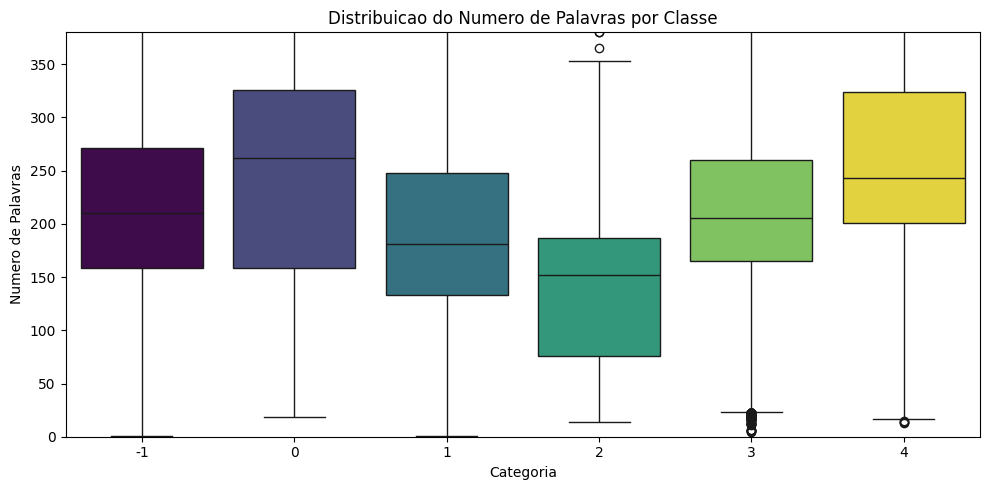

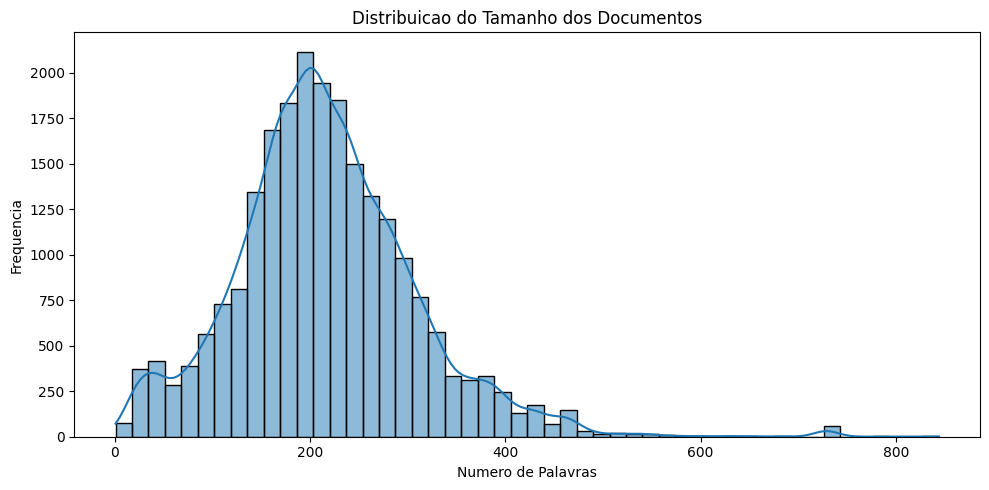

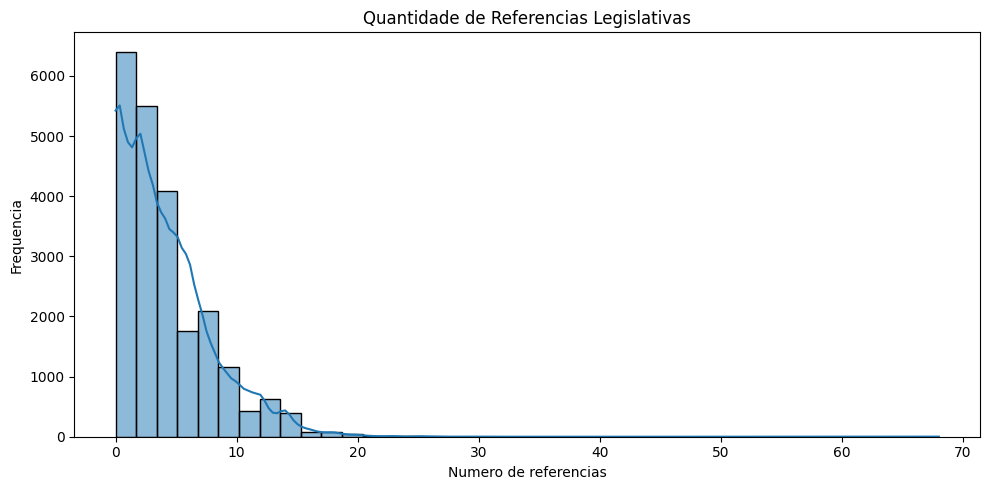

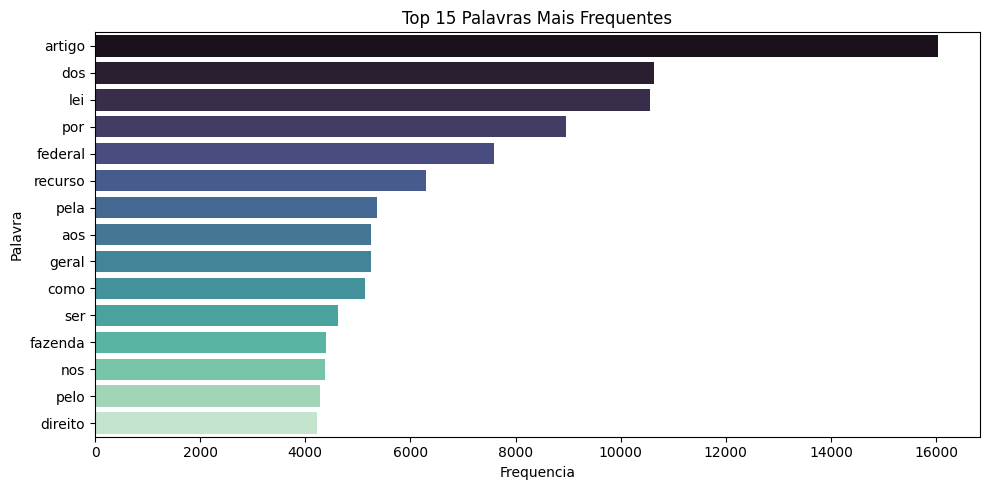

In [6]:
grafico_distribuicao_classes(df)
boxplot_tamanho_textos(df)
histograma_tamanho_textos(df)
grafico_referencias_legais(df)
palavras_frequentes(common_words)

### Constatações

1) **Distribuição das categorias**
A análise da distribuição das classes mostrou que as categorias no conjunto de treinamento possuem proporções relativamente equilibradas, sem evidências de desbalanceamentos que possam comprometer o treinamento dos modelos. Embora algumas categorias apresentem uma quantidade maior de documentos do que outras, a diferença não é significativa para justificar técnicas de balanceamento.<br>
<u><b>Conclusão</b></u>: Não será necessário aplicar técnicas de balanceamento de classes

2) **Grande variabilidade no tamanho dos documentos em geral**
As estatísticas descritivas e os gráficos de distribuição evidenciaram uma grande variação no número de palavras por documento. Foram observados documentos relativamente curtos e outros com milhares de palavras. Além disso, os boxplots mostraram a presença de diversos outliers, indicando documentos significativamente maiores que a maioria das amostras.<br>
<u><b>Conclusão</b></u>:

`!!!!!!! AVALIAR ITEM 2`

3) **Diferenças de tamanho entre categorias**
A análise do tamanho dos documentos por categoria mostrou que determinadas classes tendem a possuir documentos mais extensos que outras. Essa diferença mostra que o tamanho do texto pode carregar informação sobre a categoria.<br>
<u><b>Conclusão</b></u>: O tamanho dos documentos poderá ser utilizado como atributo auxiliar e reforça a necessidade de avaliar estratégias representação textual adequadas para textos longos.

`!!!!!!! AVALIAR ITEM 3`

4) **Vocabulário amplo e especializado**
A análise lexical revelou um vocabulário extenso, composto principalmente por termos jurídicos. <br>
<u><b>Conclusão</b></u>: Métodos de representação textual capazes de capturar contexto e semântica tendem a ser mais adequados do que abordagens baseadas apenas na frequência absoluta de palavras.

5) **Diversidade lexical distinta entre categorias**
A diversidade lexical em cada classe evidenciou diferenças na repetição do vocabulário utilizado pelos documentos. Categorias com menor diversidade lexical tendem a utilizar terminologia mais padronizada e especializada, enquanto categorias com maior diversidade apresentam vocabulário mais amplo e variado. Isso revela que determinadas áreas do direito utilizam conjuntos estáveis de termos e expressões jurídicas.<br>
<u><b>Conclusão</b></u>: As diferenças de diversidade lexical indicam que o vocabulário utilizado possui potencial discriminativo para a categorização.

6) **Existência de vocabulário característico por categoria**
A análise das palavras mais frequentes por classe revelou que algumas categorias apresentam termos recorrentes específicos que não aparecem com a mesma frequência nas demais. Isso mostra que diferentes categorias tratam de assuntos distintos, cada uma possuindo terminologia própria. Esse vocabulário especializado indica que métodos baseados em frequência de termos, como TF-IDF, poderão apresentar bom desempenho inicial. <br>
<u><b>Conclusão</b></u>: O conteúdo textual apresenta evidências claras de separabilidade entre as categorias.

7) **Referências normativas padronizadas**
Foi observado o uso frequente de menções explícitas a artigos, leis e decretos representados por tokens padronizados. Essas referências podem indicar o tema central do documento, sendo importantes para a caracterização do conteúdo dos documento, já que preservam informações semânticas relevantes e reduzem a dispersão do vocabulário.<br>
&emsp;&emsp;&nbsp;<u><b>Conclusão</b></u>: Essas referências serão mantidas e consideradas elementos importantes para a categorização.

8) **Problemas de codificação textual**
Foi identificada a ocorrência de caracteres incorretamente codificados em diversos documentos, produzindo expressões como:
    * "constituiÃ§Ã£o"
    * "decisÃ£o"
    * "jurisprudÃªncia"
Esse problema aumenta o tamanho do vocabulário e introduz ruídos nas representações textuais.

&emsp;&emsp;&nbsp;<u><b>Conclusão</b></u>: Será aplicada uma correção de codificação para reduzir ruídos e melhorar a qualidade das representações linguísticas.

9) **Frequência elevada de linguagem padronizada**
A análise das palavras mais frequentes, da diversidade lexical e dos bigramas revelou que os documentos apresentam grande padronização linguística. Foram identificadas estruturas e expressões recorrentes, tais como:
    * "diante do exposto";
    * "termos em que pede deferimento";
    * "recurso extraordinário";
    * "constituição federal";
    * "supremo tribunal";
    * "previdência social";
    * "conforme disposto no artigo".
A recorrência desses padrões reduz a variabilidade linguística e sugere que determinadas combinações de palavras possuem forte relação com as categorias.

&emsp;&emsp;&nbsp;<u><b>Conclusão</b></u>: A presença de vocabulário especializado, expressões jurídicas recorrentes e estruturas textuais padronizadas indica que representações baseadas em frequência de termos e contexto local, como Bag-of-Words, TF-IDF e n-gramas, possuem grande potencial para capturar características relevantes dos documentos. 

10) **Documentos duplicados**
Existem documentos repetidos ou extremamente semelhantes dentro do conjunto de treinamento, o que pode introduzir vieses na avaliação dos modelos, pois documentos praticamente idênticos podem aparecer em diferentes subconjuntos durante validações.<br>
<u><b>Conclusão</b></u>: Caso o percentual de duplicados seja baixo, os documentos serão mantidos. Caso contrário, será considerada a remoção de duplicatas para evitar aprendizado redundante e possíveis problemas de generalização.

`!!!!!!! AVALIAR ITEM 10`

---
### Pré-processamento

Nesta seção, as funções da etapa de pré-processamento dos dados devem ser implementadas e aplicadas (se necessário).

---
### Experimento

Nesta seção, o experimento deve ser conduzido, utilizando os protocolos experimentais padrões e testando diferentes modelos.

---
### Análise dos Resultados

Nesta seção, os resultados devem ser exibidos através de tabelas e gráficos, comparados e profundamente analisados.